## 1) Descripción del problema
Este problema trata sobre la representación de una red de bodegas mediante el uso de grafos, en esta red, cada bodega se considera como un nodo y las rutas entre ellas como conexiones, lo que permite visualizar cómo están relacionadas entre sí.

El sistema muestra un menú en el que se pueden observar distintas opciones para interactuar con la red, a través de este, se puede ver cómo se organizan los nodos y cómo se conectan, lo que facilita entender la estructura general del grafo.

También se presentan recorridos como la búsqueda en anchura y la búsqueda en profundidad, que permiten ver el orden en el que se visitan las bodegas desde un punto inicial. Esto ayuda a analizar la forma en que se puede recorrer la red y cómo se comportan sus conexiones.

En general, el problema se centra en la representación y exploración de grafos, mostrando de manera sencilla cómo funcionan las conexiones entre distintos elementos dentro de una red.



## 2) Requerimientos
##-Funcionales:

-El sistema permite agregar un nodo al grafo.

-El sistema permite añadir conexiones entre dos nodos.

-El sistema almacena el grafo mediante una lista de adyacencia.

-El sistema permite mostrar la lista de adyacencia completa.

-El sistema permite realizar un recorrido BFS desde un nodo inicial.

-El sistema permite realizar un recorrido DFS desde un nodo inicial.

-El sistema muestra en pantalla el orden de los nodos visitados.

-El sistema muestra un menú interactivo en consola.

-El sistema permite al usuario ingresar datos por teclado.

-El sistema permite seleccionar opciones mediante números.

-El sistema repite el menú hasta que el usuario decida salir.

-El sistema permite finalizar la ejecución mediante una opción.

-El sistema maneja errores cuando se ingresan opciones inválidas.

##-No funcionales:

-El sistema utiliza funciones separadas para cada operación.

-El sistema es fácil de usar mediante una interfaz de texto.

-El sistema ejecuta los recorridos de forma eficiente.

-El sistema puede ejecutarse en cualquier entorno que soporte Python.

-El sistema permite ampliar funcionalidades fácilmente.




## 3) Historias de usuario
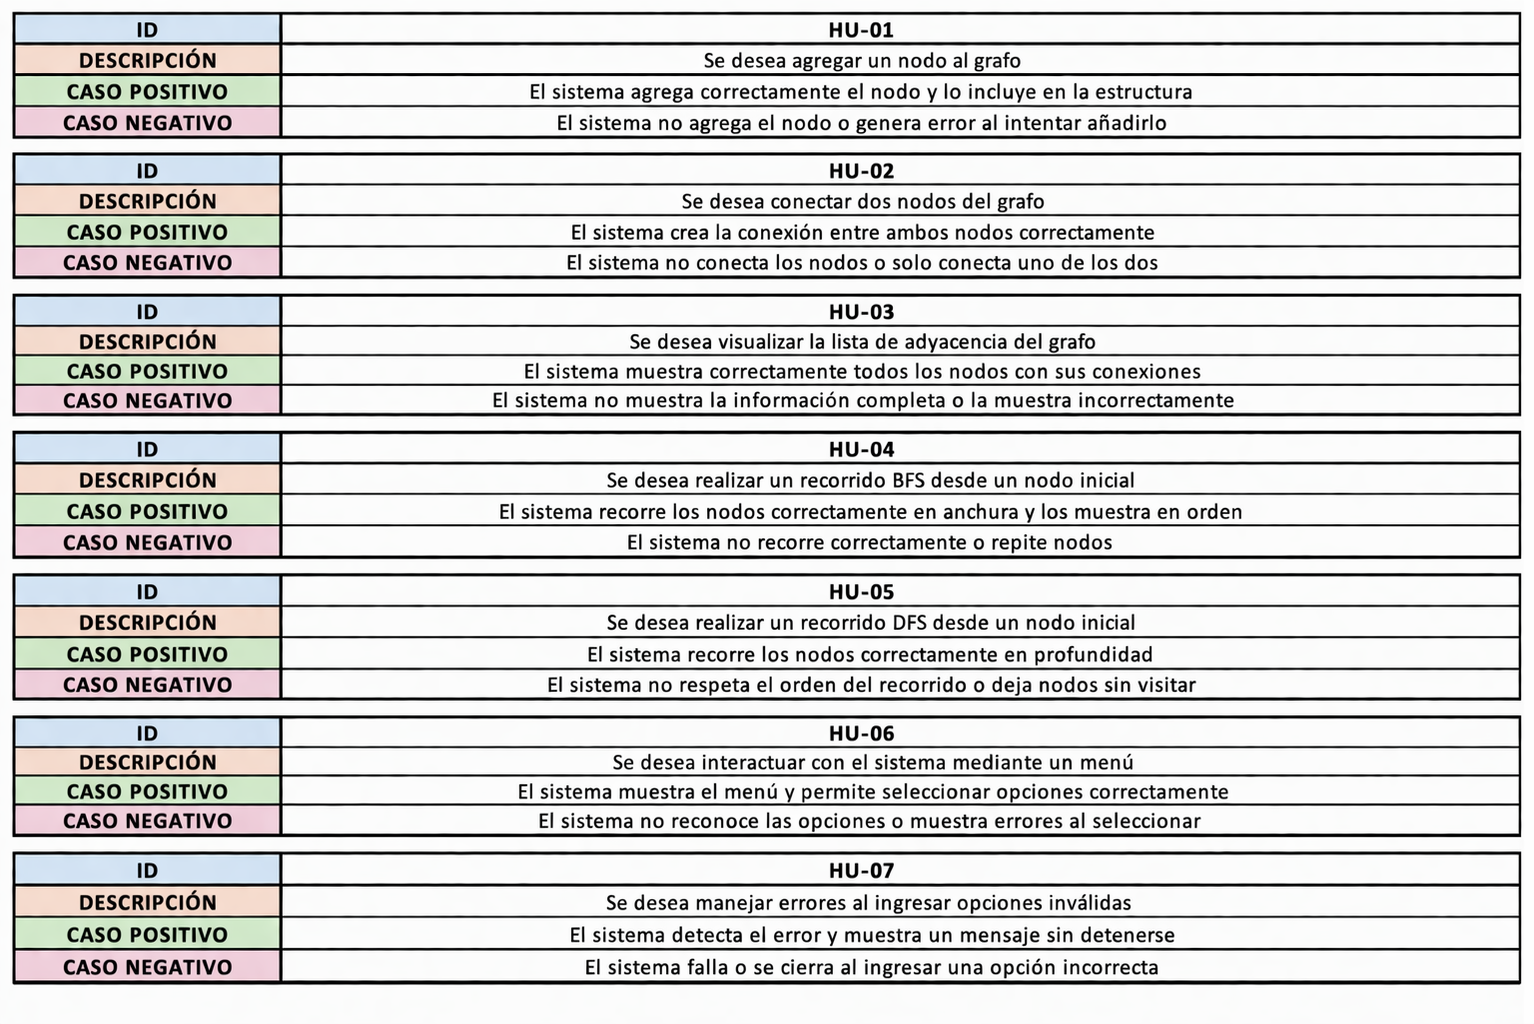

## 4) Diagramas de flujo
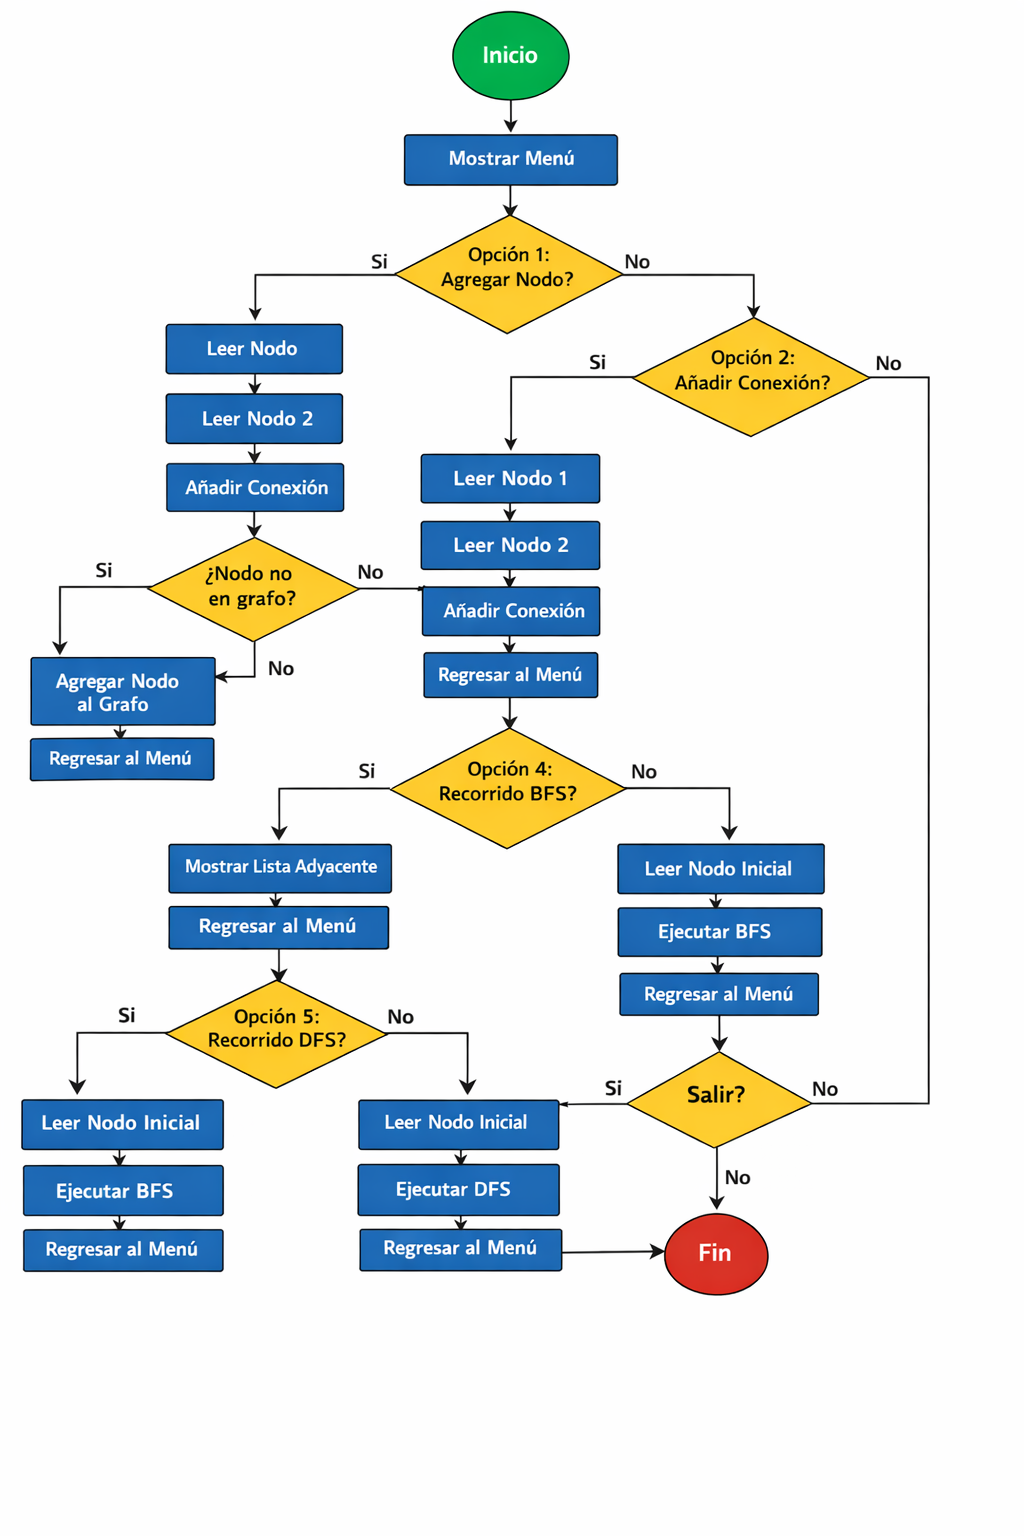



## 5) Diagramas de secuencia
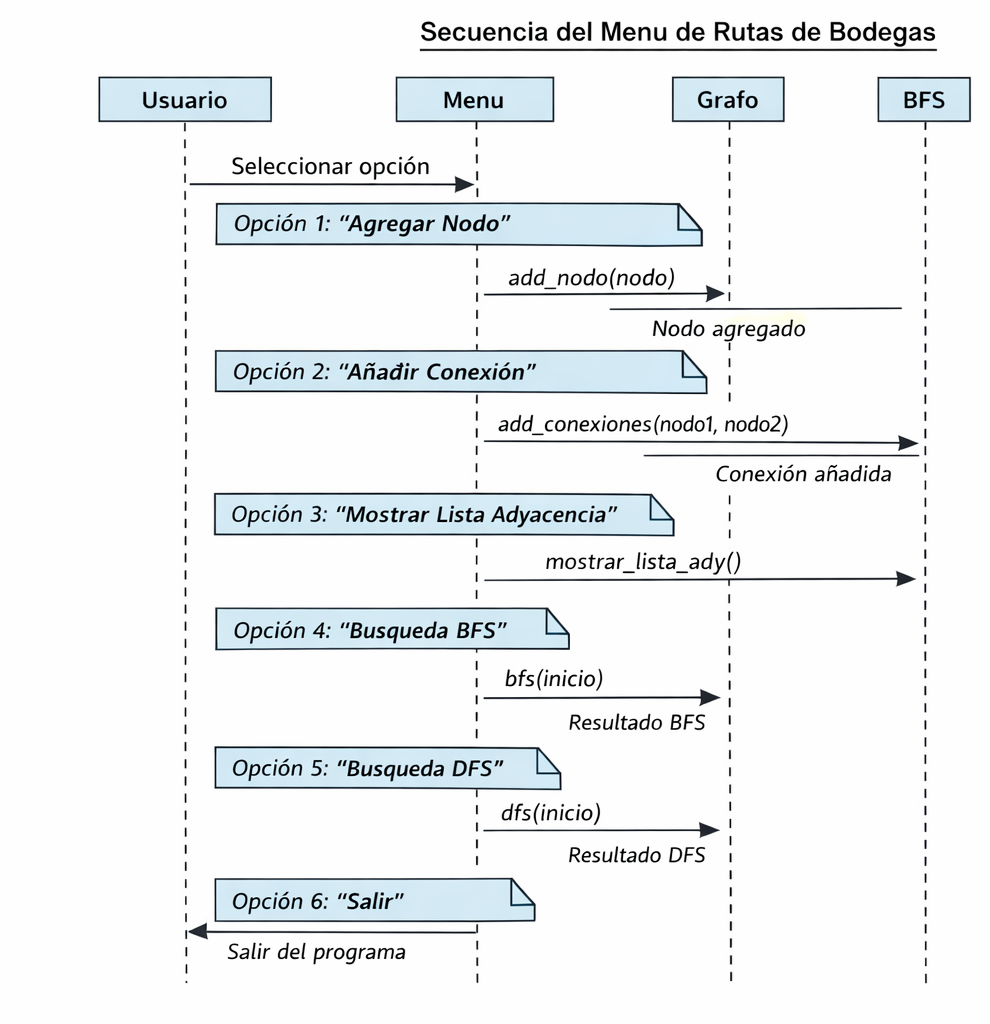

## 6) Diagramas de casos de uso
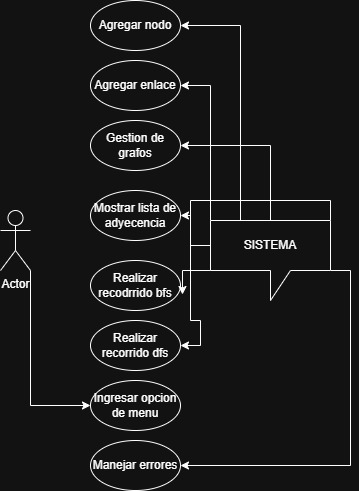


## 7) Análisis de complejidad
O(n**2)


## 8) Tests


In [ ]:
# ===== TEST 1: Agregar nodo nuevo =====
grafo = {}
add_nodo(grafo, "Z")
assert "Z" in grafo
assert grafo["Z"] == []
print("Test 1 OK")


# ===== TEST 2: Agregar nodo repetido =====
grafo = {"A": []}
add_nodo(grafo, "A")
assert len(grafo) == 1  # no se duplica
print("Test 2 OK")


# ===== TEST 3: Añadir conexión =====
grafo = {"A": [], "B": []}
add_conexiones(grafo, "A", "B")
assert "B" in grafo["A"]
assert "A" in grafo["B"]
print("Test 3 OK")


# ===== TEST 4: Recorrido BFS =====
grafo = {
    "A": ["B"],
    "B": ["A", "C"],
    "C": ["B"]
}

# Capturar salida
import io
import sys

captura = io.StringIO()
sys.stdout = captura

bfs(grafo, "A")

sys.stdout = sys.__stdout__
salida = captura.getvalue()

assert "A" in salida and "B" in salida and "C" in salida
print("Test 4 OK")


# ===== TEST 5: Recorrido DFS =====
grafo = {
    "A": ["B"],
    "B": ["A", "C"],
    "C": ["B"]
}

captura = io.StringIO()
sys.stdout = captura

dfs(grafo, "A")

sys.stdout = sys.__stdout__
salida = captura.getvalue()

assert "A" in salida and "B" in salida and "C" in salida
print("Test 5 OK")

## 9) Código funcional


In [ ]:
# ========== Agregar nodo ==========
def add_nodo(grafo, nodo):
    if  nodo not in grafo:
        grafo[nodo] = []

# ========== Agregar conexiones ==========
def add_conexiones(grafo, nodo1, nodo2):
    grafo[nodo1].append(nodo2)
    grafo[nodo2].append(nodo1)

# ========== Mostrar lista adyacentes ==========
def mostrar_lista_ady(grafo):
    for clave, valor in grafo.items():
        print(f"{clave} -----> {valor}")

# ========== Recorrido BFS ==========
def bfs(grafo, inicio):
    visitados = []
    cola = []

    cola.append(inicio)

    print("\nRecorrido BFS:")

    while len(cola) > 0:
        nodo = cola.pop(0)

        if nodo not in visitados:
            print(nodo, end=" -> ")
            visitados.append(nodo)

            for vecino in grafo[nodo]:
                cola.append(vecino)

    print("FIN")

# ========== Recorrido dfs ==========
def dfs(grafo, inicio):
    visitados = []
    pila = []

    pila.append(inicio)

    print("\nRecorrido DFS:")

    while len(pila) > 0:
        nodo = pila.pop()

        if nodo not in visitados:
            print(nodo, end=" -> ")
            visitados.append(nodo)

            for vecino in grafo[nodo]:
                pila.append(vecino)

    print("FIN")


# ========== Menu ==========
def menu():
    grafo = {"A":["A", "B", "C"],
             "B":["A", "D", "E"],
             "C":["A", "F"],
             "D":["B"],
             "E":["B", "G"],
             "F":["C", "H"],
             "G":["E", "H"],
             "H":["F", "G"]}
    while True:
        print("\n" + "=" * 47)
        print("Menu rutas de bodegas")
        print("=" * 47)
        print("1. Agregar nodo.")
        print("2. Añadir conexiones a un nodo.")
        print("3. Mostrar lista adyacencia.")
        print("4. Busqueda BFS")
        print("5. Busqueda DFS")
        print("6. Salir")
        print("=" * 47)
        try:
            option = int(input("Eliga una opcion: "))

            if option == 1:
                nodo = input("Escriba la etiqueta del nodo como una letra:  ").upper()
                print(f"➕  Se agrega al grafo el nodo: {nodo}")
                add_nodo(grafo, nodo)

            elif option == 2:
                nodo1 = input("Escriba el nodo que quiere conectar: ").upper()
                nodo2 = input(f"A que nodo desea conectar {nodo1} ↔️: ").upper()
                add_conexiones(grafo, nodo1, nodo2)
            elif option == 3:
                print("=== Lista de adyacencia ===")
                mostrar_lista_ady(grafo)
            elif option == 4:
                inicio = input("Elija el nodo inicial: ")
                bfs(grafo, inicio)
            elif option == 5:
                inicio = input("Elija el nodo inicial: ")
                dfs(grafo, inicio)
            elif option == 6:
                break
                exit("FINALIZACIÓN")
        except:
            print("⚠️" + "  " + "Elija una opcion valida")
# ========== Parte principal ==========
if __name__ == "__main__":
    menu()

## EVIDENCIA CODIGO:
 https://youtu.be/1M44vEWs0Gw